<a href="https://colab.research.google.com/github/kietietv/TH_Deep_Learning/blob/main/Tu%E1%BA%A7n_04_Thuchanh_DeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BÀI TẬP

### Bài tập 1: Viết chương trình cài đặt CNN để nhận dạng ảnh trên bộ dataset CIFAR10

In [ ]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping

# 1. Nạp và tiền xử lý dữ liệu
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 2. Xây dựng kiến trúc mô hình CNN
model_cifar = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

# 3. Biên dịch mô hình
model_cifar.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 4. TỐI ƯU: Thiết lập Early Stopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# 5. Huấn luyện mô hình (Tăng batch_size lên 128)
print("Bắt đầu huấn luyện CIFAR-10...")
history_cifar = model_cifar.fit(
    X_train, y_train,
    epochs=30,           # Cứ để 30, EarlyStopping sẽ tự ngắt nếu cần
    batch_size=128,      # Tăng lên để tính toán nhanh hơn
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

# Đánh giá
loss, accuracy = model_cifar.evaluate(X_test, y_test)
print(f"Độ chính xác CIFAR-10: {accuracy*100:.2f}%")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Bắt đầu huấn luyện CIFAR-10...
Epoch 1/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.4116 - loss: 1.6143 - val_accuracy: 0.5563 - val_loss: 1.2680
Epoch 2/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.5683 - loss: 1.2068 - val_accuracy: 0.6409 - val_loss: 1.0180
Epoch 3/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6404 - loss: 1.0279 - val_accuracy: 0.6691 - val_loss: 0.9403
Epoch 4/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6818 - loss: 0.9068 - val_accuracy: 0.6727 - val_loss: 0.9294
Epoch 5/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7129 - loss: 0.8215 - val_accuracy: 0.7199 - val_loss: 0.8104
Epoch 6/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7332 - loss: 0.7593 - val_accuracy: 0.7223 - val_loss: 0.7936
Epoch 7/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7551 - loss: 0.7017 - val_accuracy: 0.7326 - val_loss: 0.7683
Epoch 8/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.772

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 620ms/step
KẾT LUẬN: Bức ảnh này là TÀU THỦY (Độ tin cậy: 100.00%)


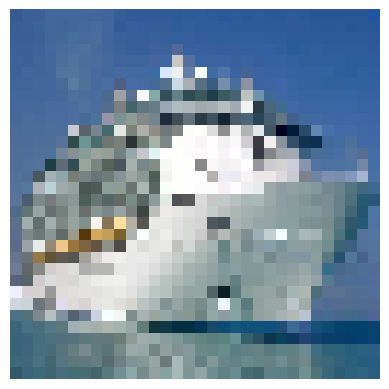

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Danh sách 10 nhãn chuẩn của bộ dữ liệu CIFAR-10
cifar10_classes = ['Máy bay', 'Ô tô', 'Chim', 'Mèo', 'Hươu',
                   'Chó', 'Ếch', 'Ngựa', 'Tàu thủy', 'Xe tải']

# 1. Khai báo đường dẫn ảnh test (Tải 1 tấm ảnh ô tô, máy bay, hoặc chó mèo... lên Colab)
img_path = '/content/test_cifar.jpg' # <-- Đổi tên file này cho đúng với ảnh của bạn

# 2. Đọc ảnh và ép kích thước về 32x32 pixel (Vì CIFAR-10 là ảnh màu nên giữ nguyên, không cần grayscale)
img = image.load_img(img_path, target_size=(32, 32))

# 3. Chuyển thành ma trận và chuẩn hóa pixel (0-1)
img_array = image.img_to_array(img)
img_array = img_array / 255.0

# 4. Thêm chiều batch, biến ma trận từ (32, 32, 3) thành (1, 32, 32, 3)
img_array = np.expand_dims(img_array, axis=0)

# 5. Đưa vào mô hình CIFAR-10 dự báo
predictions = model_cifar.predict(img_array)

# 6. Trích xuất kết quả
predicted_class_index = np.argmax(predictions[0])
predicted_class_name = cifar10_classes[predicted_class_index]
do_tin_cay = np.max(predictions[0]) * 100

print(f"KẾT LUẬN: Bức ảnh này là {predicted_class_name.upper()} (Độ tin cậy: {do_tin_cay:.2f}%)")

# Hiển thị bức ảnh gốc ra màn hình (lưu ý ảnh 32x32 sẽ khá mờ và vỡ hạt)
plt.imshow(img)
plt.axis('off')
plt.show()

### Bài tập 2: Viết chương trình cài đặt CNN để nhận dạng ảnh Cat hoặc Dog

In [ ]:
import os
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
# from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import EarlyStopping
import tensorflow_datasets as tfds

# 1. Nạp và tiền xử lý dữ liệu từ tensorflow_datasets
# tfds.load handles downloading and splitting, ensuring data accessibility.
(raw_train, raw_test), metadata = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:]'], # Split the 'train' split into train and validation
    with_info=True,
    as_supervised=True, # Returns (image, label) tuples
)

# Define preprocessing function for resizing and normalization
IMG_WIDTH = 64
IMG_HEIGHT = 64

def format_example(image, label):
    image = tf.cast(image, tf.float32)
    image = image / 255.0
    image = tf.image.resize(image, (IMG_WIDTH, IMG_HEIGHT))
    return image, label

# Apply preprocessing and batching to the datasets
BATCH_SIZE = 64

# Use a specific positive integer for shuffle buffer size
SHUFFLE_BUFFER_SIZE = 10000 # A sufficiently large number for shuffling
PREFETCH_BUFFER_SIZE = tf.data.AUTOTUNE # tf.data.AUTOTUNE is fine for prefetch

train_dataset = raw_train.map(format_example).shuffle(SHUFFLE_BUFFER_SIZE).batch(BATCH_SIZE).prefetch(buffer_size=PREFETCH_BUFFER_SIZE)
test_dataset = raw_test.map(format_example).batch(BATCH_SIZE).prefetch(buffer_size=PREFETCH_BUFFER_SIZE)

# No longer need 'train_dir', 'test_dir', or ImageDataGenerator.flow_from_directory

# 3. Xây dựng mô hình CNN (Đổi input_shape cho khớp với 64x64)
model_catdog = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid') # Binary -> sigmoid
])

# 4. Biên dịch mô hình
model_catdog.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Huấn luyện với Early Stopping
early_stop_cd = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Bắt đầu huấn luyện Cat vs Dog...")
history_catdog = model_catdog.fit(
    train_dataset,
    epochs=20,
    validation_data=test_dataset,
    callbacks=[early_stop_cd]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Bắt đầu huấn luyện Cat vs Dog...
Epoch 1/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 36s 67ms/step - accuracy: 0.6616 - loss: 0.6099 - val_accuracy: 0.7307 - val_loss: 0.5360
Epoch 2/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 28s 59ms/step - accuracy: 0.7606 - loss: 0.5004 - val_accuracy: 0.7805 - val_loss: 0.4661
Epoch 3/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 29s 63ms/step - accuracy: 0.7930 - loss: 0.4489 - val_accuracy: 0.7681 - val_loss: 0.4816
Epoch 4/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 33s 74ms/step - accuracy: 0.8160 - loss: 0.4008 - val_accuracy: 0.8037 - val_loss: 0.4359
Epoch 5/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 28s 59ms/step - accuracy: 0.8395 - loss: 0.3596 - val_accuracy: 0.7982 - val_loss: 0.4406
Epoch 6/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 28s 62ms/step - accuracy: 0.8590 - loss: 0.3230 - val_accuracy: 0.8070 - val_loss: 0.4252
Epoch 7/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 27s 57ms/step - accuracy: 0.8827 - loss: 0.2802 - val_accuracy: 0.8098 - val_loss: 0.4258
Epoch 8/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 28s 58ms/step - a

Đang tiến hành dự báo...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 701ms/step
Xác suất mô hình tính toán được: 0.8043
KẾT LUẬN: ĐÂY LÀ CON CHÓ


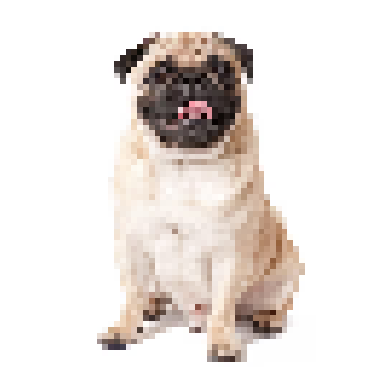

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras.preprocessing import image

# 1. Đường dẫn tới ảnh bạn vừa upload
img_path = '/content/test_cat_or_dog.jpg' # Đổi tên file cho đúng với ảnh của bạn

# 2. Đọc và Resize ảnh về đúng kích thước lúc huấn luyện (64x64)
img = image.load_img(img_path, target_size=(64, 64))

# 3. Chuyển ảnh thành mảng ma trận (Array)
img_array = image.img_to_array(img)

# 4. Chuẩn hóa pixel về khoảng 0-1 (Giống rescale=1./255 lúc train)
img_array = img_array / 255.0

# 5. Keras yêu cầu đầu vào phải có chiều "Batch", nên ta phải mở rộng mảng từ 3D (64,64,3) thành 4D (1,64,64,3)
img_array = np.expand_dims(img_array, axis=0)

# 6. Đưa vào mô hình dự báo
print("Đang tiến hành dự báo...")
prediction = model_catdog.predict(img_array)
xac_suat = prediction[0][0]

# 7. Đọc kết quả (Vì dùng activation='sigmoid' nên kết quả trả về là xác suất từ 0 đến 1)
# Thông thường: Data generator gán theo alphabet: C (Cat) là 0, D (Dog) là 1
print(f"Xác suất mô hình tính toán được: {xac_suat:.4f}")

if xac_suat >= 0.5:
    print("KẾT LUẬN: ĐÂY LÀ CON CHÓ")
else:
    print("KẾT LUẬN: ĐÂY LÀ CON MÈO")

# Hiển thị bức ảnh lên màn hình để kiểm chứng
plt.imshow(img)
plt.axis('off')
plt.show()

### Bài tập 3: Nhận dạng ảnh Fashion-MNIST

In [ ]:
import tensorflow as tf
import numpy as np
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping

# 1. Tải bộ dataset Fashion MNIST có sẵn của TensorFlow
fashion = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion.load_data()

# TỐI ƯU TIỀN XỬ LÝ:
# CNN cần shape là (dài, rộng, kênh màu). Ảnh đen trắng có kênh màu = 1
X_train = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# Chuyển nhãn (0-9) thành One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 2. Xây dựng kiến trúc mô hình CNN
model_fashion = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

# 3. Biên dịch mô hình
model_fashion.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 4. Huấn luyện với Early Stopping và batch_size lớn
early_stop_fm = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Bắt đầu huấn luyện Fashion MNIST...")
history_fashion = model_fashion.fit(
    X_train, y_train,
    epochs=25,
    batch_size=128, # Xử lý 128 ảnh một lúc để tăng tốc độ
    validation_data=(X_test, y_test),
    callbacks=[early_stop_fm]
)

# Đánh giá
loss, accuracy = model_fashion.evaluate(X_test, y_test)
print(f"Độ chính xác Fashion-MNIST: {accuracy*100:.2f}%")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Bắt đầu huấn luyện Fashion MNIST...
Epoch 1/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.7859 - loss: 0.5937 - val_accuracy: 0.8524 - val_loss: 0.4057
Epoch 2/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8641 - loss: 0.3775 - val_accuracy: 0.8767 - val_loss: 0.3374
Epoch 3/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8808 - loss: 0.3280 - val_accuracy: 0.8862 - val_loss: 0.3181
Epoch 4/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8914 - loss: 0.2977 - val_accuracy: 0.8950 - val_loss: 0.2892
Epoch 5/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8998 - loss: 0.2755 - val_accuracy: 0.9002 - val_loss: 0.2742
Epoch 6/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9061 - loss: 0.2553 - val_accuracy: 0.8991 - val_loss: 0.2783
Epoch 7

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
KẾT LUẬN: Đây là Ankle boot (Độ tin cậy: 99.72%)


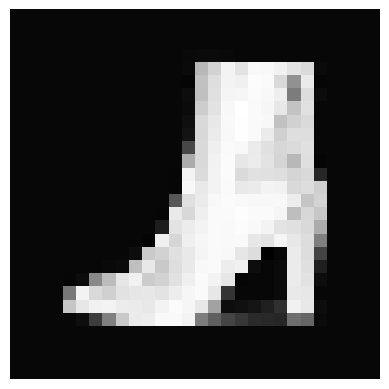

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from PIL import ImageOps

# Danh sách tên 10 nhãn của Fashion MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 1. Khai báo đường dẫn ảnh test
img_path = '/content/test_fashion_mnist.png' # Đổi tên thành file của bạn

# 2. Đọc ảnh, ép về ảnh xám (color_mode='grayscale') và kích thước 28x28
img = image.load_img(img_path, target_size=(28, 28), color_mode="grayscale")

# --- BƯỚC ĐẢO MÀU (Nếu ảnh của bạn tải từ Google nền trắng, hình đen) ---
# Nếu ảnh gốc vốn dĩ nền đen hình trắng rồi thì bạn CÓ THỂ XÓA DÒNG NÀY
img = ImageOps.invert(img)
# ----------------------------------------------------------------------

# 3. Chuyển thành ma trận và chuẩn hóa
img_array = image.img_to_array(img)
img_array = img_array / 255.0

# 4. Thêm chiều batch, thành shape (1, 28, 28, 1)
img_array = np.expand_dims(img_array, axis=0)

# 5. Dự báo
predictions = model_fashion.predict(img_array)

# Hàm softmax trả về 1 mảng gồm 10 xác suất, ta dùng argmax để lấy vị trí có xác suất cao nhất
predicted_class_index = np.argmax(predictions[0])
predicted_class_name = class_names[predicted_class_index]
do_tin_cay = np.max(predictions[0]) * 100

print(f"KẾT LUẬN: Đây là {predicted_class_name} (Độ tin cậy: {do_tin_cay:.2f}%)")

# Hiển thị ảnh (dùng cmap='gray' để hiện ảnh trắng đen)
plt.imshow(img_array[0, :, :, 0], cmap='gray')
plt.axis('off')
plt.show()

# Triển khai CNN

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, GlobalMaxPooling1D, Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

In [ ]:
# Đọc tập dữ liệu
train_df = pd.read_csv('UIT-VSFC_train_processed.csv')
valid_df = pd.read_csv('UIT-VSFC_valid_processed.csv')
test_df  = pd.read_csv('UIT-VSFC_test_processed.csv')

# Lấy dữ liệu Input (Văn bản) và Output (Nhãn)
# Cần ép kiểu về string để tránh lỗi nếu có giá trị rỗng (NaN)
X_train_text = train_df['tokenized_text'].astype(str).values
y_train      = train_df['label_id'].values

X_valid_text = valid_df['tokenized_text'].astype(str).values
y_valid      = valid_df['label_id'].values

X_test_text  = test_df['tokenized_text'].astype(str).values
y_test       = test_df['label_id'].values

In [ ]:
# Khai báo số lượng từ vựng tối đa và chiều dài câu tối đa
vocab_size = 10000
max_length = 50     # Xem cột token_count, hầu hết câu < 50 từ
embedding_dim = 100 # Số chiều cho vector biểu diễn từ

# Khởi tạo và huấn luyện bộ từ điển Tokenizer
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

# Chuyển chữ thành số
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_valid_seq = tokenizer.texts_to_sequences(X_valid_text)
X_test_seq  = tokenizer.texts_to_sequences(X_test_text)

# Padding (đệm số 0) để mọi câu đều dài đúng bằng max_length
X_train = pad_sequences(X_train_seq, maxlen=max_length, padding='post', truncating='post')
X_valid = pad_sequences(X_valid_seq, maxlen=max_length, padding='post', truncating='post')
X_test  = pad_sequences(X_test_seq,  maxlen=max_length, padding='post', truncating='post')

In [ ]:
num_classes = 3
y_train_hot = to_categorical(y_train, num_classes)
y_valid_hot = to_categorical(y_valid, num_classes)
y_test_hot  = to_categorical(y_test, num_classes)

In [ ]:
model = Sequential()
# 1. Tầng Embedding: Ánh xạ mỗi từ (số nguyên) thành vector có chiều dài embedding_dim
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length))

# 2. Tầng Convolutional 1D: Tìm các đặc trưng cục bộ (các cụm từ biểu hiện cảm xúc)
model.add(Conv1D(filters=128, kernel_size=5, activation='relu'))

# 3. Tầng Pooling: Lấy đặc trưng nổi bật nhất của câu, đồng thời làm phẳng dữ liệu
model.add(GlobalMaxPooling1D())

# 4. Tầng Dense (Fully Connected) phân loại
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5)) # Tránh over-fitting
model.add(Dense(num_classes, activation='softmax')) # 3 đầu ra cho 3 nhãn

# Compile mô hình
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
epochs = 10
batch_size = 64

history = model.fit(
    X_train, y_train_hot,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_valid, y_valid_hot),
    verbose=1
)

Epoch 1/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - accuracy: 0.8088 - loss: 0.4853 - val_accuracy: 0.9021 - val_loss: 0.2802
Epoch 2/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.9154 - loss: 0.2642 - val_accuracy: 0.9198 - val_loss: 0.2440
Epoch 3/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.9366 - loss: 0.2036 - val_accuracy: 0.9223 - val_loss: 0.2372
Epoch 4/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.9539 - loss: 0.1537 - val_accuracy: 0.9248 - val_loss: 0.2479
Epoch 5/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.9664 - loss: 0.1145 - val_accuracy: 0.9210 - val_loss: 0.2717
Epoch 6/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.9768 - loss: 0.0840 - val_accuracy: 0.9261 - val_loss: 0.3009
Epoch 7/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.9829 - loss: 0.0580 - val_accuracy: 0.9261 - val_loss: 0.3126
Epoch 8/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.9881 - loss: 0.0421 - val_ac

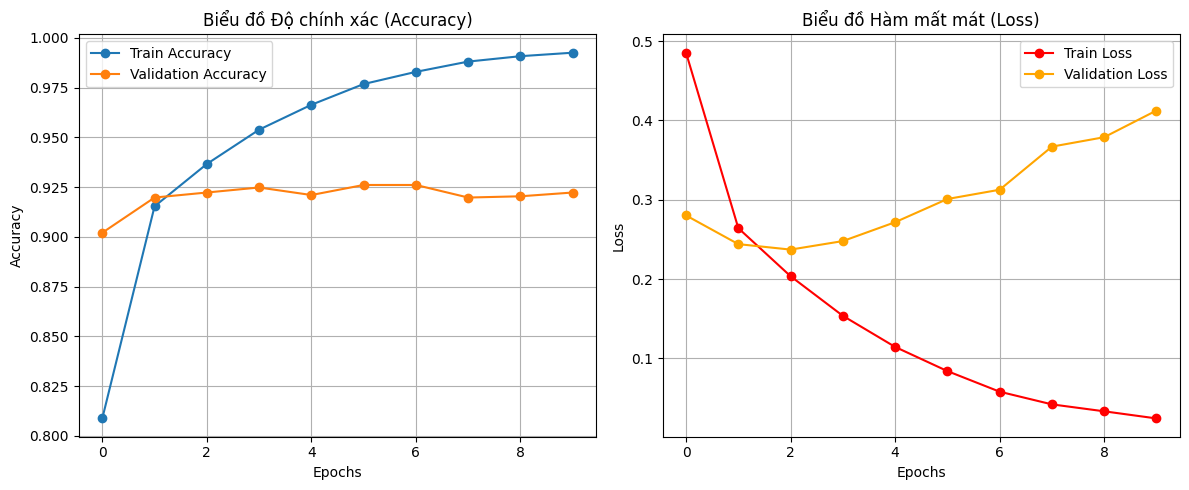

In [ ]:
import matplotlib.pyplot as plt

# Tạo một khung vẽ gồm 2 biểu đồ (1 hàng, 2 cột) với kích thước rộng rãi
plt.figure(figsize=(12, 5))

# 1. Vẽ biểu đồ Độ chính xác (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Biểu đồ Độ chính xác (Accuracy)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True) # Thêm lưới cho dễ nhìn

# 2. Vẽ biểu đồ Hàm mất mát (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o', color='orange')
plt.title('Biểu đồ Hàm mất mát (Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Hiển thị
plt.tight_layout()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test_hot, verbose=0)
print(f"Độ chính xác trên tập Test: {test_acc*100:.2f}%")

Độ chính xác trên tập Test: 89.64%


In [ ]:
# Bình luận sinh viên mẫu
sample_comments = [
    "thầy giảng rất hay và nhiệt tình", # Tích cực (2)
    "slide quá mờ và phòng máy tính bị hỏng nhiều", # Tiêu cực (0)
]

# Tiền xử lý
sample_seqs = tokenizer.texts_to_sequences(sample_comments)
sample_padded = pad_sequences(sample_seqs, maxlen=max_length, padding='post', truncating='post')

# Dự báo
predictions = model.predict(sample_padded)
labels = ["Tiêu cực", "Trung lập", "Tích cực"]

for i, text in enumerate(sample_comments):
    pred_label = np.argmax(predictions[i])
    print(f"Bình luận: '{text}' --> Dự báo: {labels[pred_label]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
Bình luận: 'thầy giảng rất hay và nhiệt tình' --> Dự báo: Tích cực
Bình luận: 'slide quá mờ và phòng máy tính bị hỏng nhiều' --> Dự báo: Tiêu cực


In [ ]:
# Lưu cấu trúc và trọng số
model.save("Text_CNN_UIT_VSFC.h5")
print("Đã lưu mô hình CNN!")

Đã lưu mô hình CNN!


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Định nghĩa danh sách nhãn tương ứng với ID (0, 1, 2)
labels = ["Tiêu cực", "Trung lập", "Tích cực"]

print("=== CHƯƠNG TRÌNH DỰ BÁO CẢM XÚC BÌNH LUẬN ===")
print("Nhập chữ 'thoat' để dừng chương trình.\n")

while True:
    # 1. Chờ người dùng nhập bình luận từ bàn phím
    user_input = input("Nhập bình luận của sinh viên: ")

    # Kịch bản thoát chương trình
    if user_input.strip().lower() == 'thoat':
        print("Đã đóng chương trình dự báo!")
        break

    # Bỏ qua nếu người dùng không nhập gì mà nhấn Enter
    if user_input.strip() == "":
        print("Vui lòng không để trống!")
        continue

    # 2. Tiền xử lý chuỗi văn bản vừa nhập
    # Lưu ý: 'tokenizer' và 'max_length' lấy từ các bước huấn luyện trước đó
    input_seq = tokenizer.texts_to_sequences([user_input])
    input_padded = pad_sequences(input_seq, maxlen=max_length, padding='post', truncating='post')

    # 3. Đưa vào mô hình CNN để dự báo
    # verbose=0 giúp ẩn thanh progress bar đi cho giao diện sạch sẽ
    prediction = model.predict(input_padded, verbose=0)

    # 4. Giải mã kết quả
    pred_label_index = np.argmax(prediction)        # Lấy vị trí có xác suất cao nhất
    pred_label_name = labels[pred_label_index]      # Suy ra tên nhãn
    confidence = prediction[0][pred_label_index] * 100 # Tính phần trăm độ tin cậy

    # 5. In kết quả ra màn hình
    print(f"--> Kết quả dự báo: {pred_label_name} (Độ tin cậy: {confidence:.2f}%)\n")
    print("-" * 50)